<a href="https://colab.research.google.com/github/lorenabao/Basics-Python/blob/main/GoodReads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Clonar el repositorio desde GitHub
!git clone https://github.com/zygmuntz/goodbooks-10k.git

Cloning into 'goodbooks-10k'...
remote: Enumerating objects: 66, done.
remote: Total 66 (delta 0), reused 0 (delta 0), pack-reused 66 (from 1)
Receiving objects: 100% (66/66), 118.23 MiB | 22.17 MiB/s, done.
Resolving deltas: 100% (17/17), done.
Updating files: 100% (20/20), done.


In [3]:
# 2. Cambiar al directorio del dataset
%cd goodbooks-10k

/content/goodbooks-10k/goodbooks-10k


In [62]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
books = pd.read_csv("books.csv")
ratings = pd.read_csv("ratings.csv")
to_read = pd.read_csv("to_read.csv")
book_tags = pd.read_csv("book_tags.csv")
tags = pd.read_csv("tags.csv")

print("📚 Books:")
print(books.head())

print("\n⭐ Ratings:")
print(ratings.head())

print("\n📌 To Read:")
print(to_read.head())

print("\n🏷️ Book Tags:")
print(book_tags.head())

print("\n🏷️ Tags:")
print(tags.head())

📚 Books:
   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee                     1960.0   
4  9.780743e+12          F. Scott Fitzgerald                     1925.0   

                             original_title  ... ratings_co

In [7]:
books.head().columns.tolist()

['book_id',
 'goodreads_book_id',
 'best_book_id',
 'work_id',
 'books_count',
 'isbn',
 'isbn13',
 'authors',
 'original_publication_year',
 'original_title',
 'title',
 'language_code',
 'average_rating',
 'ratings_count',
 'work_ratings_count',
 'work_text_reviews_count',
 'ratings_1',
 'ratings_2',
 'ratings_3',
 'ratings_4',
 'ratings_5',
 'image_url',
 'small_image_url']

In [8]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [28]:
# Filtrar solo los que tienen "harry" en el título (de forma segura)
harry_books = books[books['original_title'].str.contains('harry', flags=re.IGNORECASE, na=False)]

# Ordenar alfabéticamente
harry_books = harry_books.sort_values(by='original_title')

# Confirmar que todos contienen "harry"
s1 = harry_books['title'].str.contains('harry', flags=re.IGNORECASE).all()

harry_books['title']

,title
1416,Chasing Harry Winston
421,"Harry Potter Boxset (Harry Potter, #1-7)"
5239,"The Redeemer (Harry Hole, #6)"
2100,"The Harry Potter Collection 1-4 (Harry Potter,..."
3752,"Harry Potter Collection (Harry Potter, #1-6)"
3735,Harry Potter Page to Screen: The Complete Film...
9282,Harry Potter and Philosophy: If Aristotle Ran ...
22,Harry Potter and the Chamber of Secrets (Harry...
3053,Harry Potter and the Chamber of Secrets: Sheet...
278,Harry Potter and the Cursed Child - Parts One ...


In [74]:
author = books[books['authors'].str.contains('michio kaku', flags=re.IGNORECASE)]

author['authors'].value_counts()

michio = author[['title', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']]

In [75]:
michio['total_ratings'] = michio[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']].sum(axis=1)


/tmp/ipython-input-971421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  michio['total_ratings'] = michio[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']].sum(axis=1)


In [76]:
michio['avg_rating'] = (
    michio['ratings_1'] * 1 +
    michio['ratings_2'] * 2 +
    michio['ratings_3'] * 3 +
    michio['ratings_4'] * 4 +
    michio['ratings_5'] * 5
) / michio['total_ratings']


michio_sorted = michio.sort_values(by='total_ratings', ascending=False)
michio_sorted[['title', 'total_ratings']]

/tmp/ipython-input-2336351450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  michio['avg_rating'] = (


,title,total_ratings
3788,Physics of the Impossible: A Scientific Explor...,24597
6218,Hyperspace,15150
6780,"Parallel Worlds: A Journey Through Creation, H...",13385
8552,Physics of the Future: How Science Will Shape ...,11605


In [77]:
michio

,title,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,total_ratings,avg_rating
3788,Physics of the Impossible: A Scientific Explor...,605,964,4342,8934,9752,24597,4.067772
6218,Hyperspace,276,624,2622,5315,6313,15150,4.106601
6780,"Parallel Worlds: A Journey Through Creation, H...",159,427,2128,4998,5673,13385,4.165409
8552,Physics of the Future: How Science Will Shape ...,212,532,2463,4461,3937,11605,3.980526


/tmp/ipython-input-1856287830.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


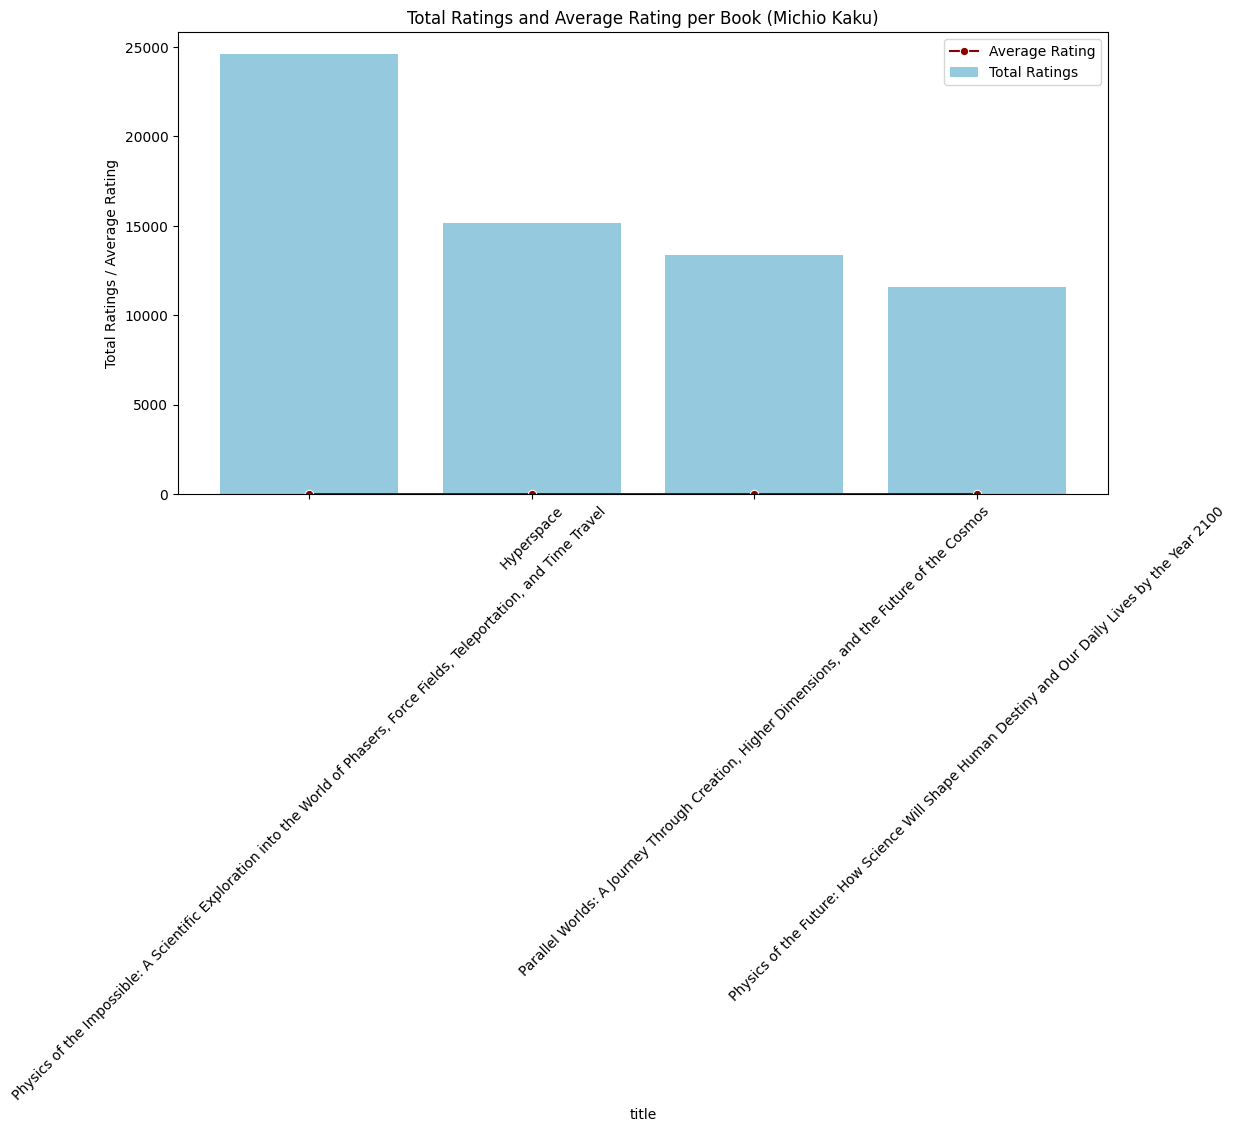

In [79]:
plt.figure(figsize=(12, 6))
sns.barplot(data=michio_sorted, x='title', y='total_ratings', color='skyblue', label='Total Ratings')
sns.lineplot(data=michio_sorted, x='title', y='avg_rating', color='darkred', marker='o', label='Average Rating')
plt.xticks(rotation=90)
plt.ylabel("Total Ratings / Average Rating")
plt.title("Total Ratings and Average Rating per Book (Michio Kaku)")
plt.legend()
plt.tight_layout()
plt.show()